# Estimação Intervalar
### Teorema Central do Limite, intervalo de confiança para média e para proporção

Até aqui, os módulos anteriores descreveram dados (Módulo 01) e modelaram o
comportamento teórico de uma variável aleatória (Módulos 02 e 03). A partir daqui, o
problema se inverte: **dada uma amostra, o que dá para afirmar sobre a população** que a
gerou — com que grau de confiança?

Pré-requisito: [Módulo 03 — Distribuições de Probabilidade](../03_Distribuições_de_Probabilidade)

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'font.size': 12})
rng = np.random.default_rng(42)

## 1. Teorema Central do Limite

Uma das ideias mais úteis da estatística: **a distribuição das médias de amostras**
tiradas de uma população — qualquer que seja o formato da população — se aproxima de uma
Normal à medida que o tamanho da amostra $n$ cresce, com:

$$E(\bar{X}) = \mu \qquad\qquad Var(\bar{X}) = \frac{\sigma^2}{n}$$

Isso vale mesmo quando a população original **não é normal** — é o que torna a inferência
estatística possível na prática. Para ver isso, simulamos uma população bem
"não-normal" (uma Exponencial, bem assimétrica) e comparamos a distribuição de milhares
de médias amostrais para diferentes tamanhos de amostra.

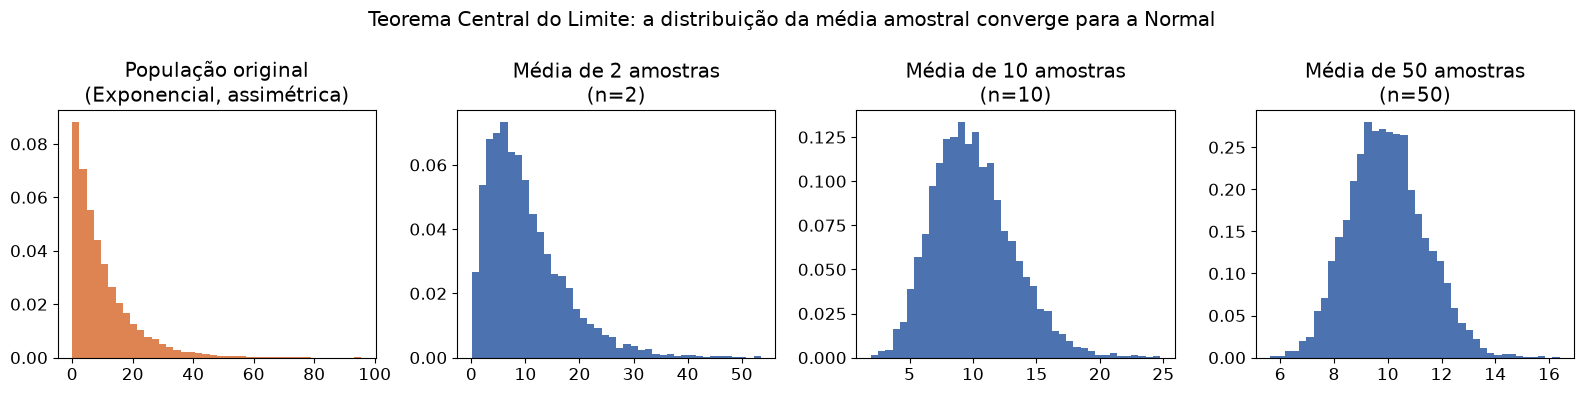

In [2]:
populacao = stats.expon(scale=10)  # população fortemente assimétrica (não-normal)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

# Painel 0: a população original
amostra_pop = populacao.rvs(size=20000, random_state=rng)
axes[0].hist(amostra_pop, bins=40, color='#DD8452', density=True)
axes[0].set_title('População original\n(Exponencial, assimétrica)')

# Painéis 1-3: distribuição da média amostral para n = 2, 10, 50
for ax, n in zip(axes[1:], [2, 10, 50]):
    medias = populacao.rvs(size=(5000, n), random_state=rng).mean(axis=1)
    ax.hist(medias, bins=40, color='#4C72B0', density=True)
    ax.set_title(f'Média de {n} amostras\n(n={n})')

fig.suptitle('Teorema Central do Limite: a distribuição da média amostral converge para a Normal')
plt.tight_layout()
plt.savefig('img_teorema_central_limite.png', dpi=110)
plt.show()

Com $n=2$ a distribuição da média ainda é bem assimétrica (herda o formato da
população). Com $n=50$, já é visualmente indistinguível de uma Normal — mesmo a
população de origem sendo tão distante de uma Normal quanto uma Exponencial. Na prática,
$n \geq 30$ costuma ser considerado "grande o suficiente" para essa aproximação.

## 2. Estimação pontual x estimação intervalar

Uma **estimativa pontual** é um único número (ex: a média amostral $\bar{x}$ como
estimativa de $\mu$) — mas não diz nada sobre o quão confiável ele é. Uma **estimativa
intervalar** (intervalo de confiança) dá uma faixa de valores plausíveis, associada a um
**nível de confiança** (ex: 95%):

$$\text{estimativa pontual} \pm \text{margem de erro}$$

O nível de confiança de 95% não significa "95% de chance de $\mu$ estar no intervalo" —
$\mu$ é fixo, não aleatório. Significa que, se repetíssemos o processo de amostragem
muitas vezes, cerca de 95% dos intervalos construídos conteriam o verdadeiro $\mu$.

## 3. Intervalo de confiança para a média — desvio-padrão populacional conhecido

Quando $\sigma$ (populacional) é conhecido, o intervalo de confiança usa a distribuição
Normal padrão:

$$\bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

### Exemplo — preço de um produto no varejo

Um levantamento de preços de um produto em 6 lojas de um bairro (população de 30 lojas)
resultou nos valores (em u.m./kg): 6,4; 7,3; 5,8; 6,5; 7,0; 6,0. O desvio padrão dos
preços deste produto, conhecido de levantamentos anteriores em mercados semelhantes, é
$\sigma = 0{,}5$. Qual o intervalo de 90% de confiança para o preço médio no bairro?

In [3]:
precos = np.array([6.4, 7.3, 5.8, 6.5, 7.0, 6.0])
sigma = 0.5
n = len(precos)
confianca = 0.90

media = precos.mean()
z = stats.norm.ppf(1 - (1 - confianca) / 2)
margem = z * sigma / math.sqrt(n)

print(f"média amostral = {media:.4f}")
print(f"z (90%) = {z:.4f}")
print(f"margem de erro (sem correção) = {margem:.4f}")
print(f"IC 90%: ({media - margem:.4f}, {media + margem:.4f})")

média amostral = 6.5000
z (90%) = 1.6449
margem de erro (sem correção) = 0.3358
IC 90%: (6.1642, 6.8358)


## 4. Correção para população finita

A fórmula acima assume implicitamente uma população infinita (ou amostragem com
reposição). Quando a amostra representa uma **fração considerável** de uma população
finita e conhecida de tamanho $N$ (regra prática: $n/N > 5\%$), aplica-se o **fator de
correção para população finita** (fpc), que reduz a margem de erro:

$$\text{fpc} = \sqrt{\frac{N-n}{N-1}} \qquad\qquad \bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}} \cdot \text{fpc}$$

No exemplo anterior, a amostra de 6 lojas veio de uma população de apenas $N=30$ lojas —
$6/30 = 20\%$, bem acima do limiar de 5%, então a correção é necessária.

In [4]:
N = 30
fpc = math.sqrt((N - n) / (N - 1))
margem_corrigida = z * sigma / math.sqrt(n) * fpc

print(f"fator de correção (fpc) = {fpc:.4f}")
print(f"margem de erro (com correção) = {margem_corrigida:.4f}")
print(f"IC 90% corrigido: ({media - margem_corrigida:.4f}, {media + margem_corrigida:.4f})")
print()
print(f"A correção reduz a margem de erro em {(1 - fpc):.1%} — faz sentido: quando a")
print("amostra já cobre boa parte da população, sobra menos incerteza sobre o resto.")

fator de correção (fpc) = 0.9097
margem de erro (com correção) = 0.3054
IC 90% corrigido: (6.1946, 6.8054)

A correção reduz a margem de erro em 9.0% — faz sentido: quando a
amostra já cobre boa parte da população, sobra menos incerteza sobre o resto.


## 5. Intervalo de confiança para a média — desvio-padrão populacional desconhecido

O caso mais comum na prática: só temos o desvio padrão **amostral** $s$. Nesse caso, a
margem de erro usa a distribuição **t de Student** (Módulo 03) com $n-1$ graus de
liberdade, não mais a Normal:

$$\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$

### Exemplo — comprimento de peças produzidas por uma máquina

Uma amostra de 15 peças produzidas por uma máquina forneceu um comprimento médio de
20 mm com desvio padrão amostral de 0,1 mm. Assumindo distribuição normal do
comprimento, qual o intervalo de 95% de confiança para o comprimento médio real?

In [5]:
x_barra, s, n2 = 20.0, 0.1, 15
confianca2 = 0.95
df = n2 - 1

t_critico = stats.t.ppf(1 - (1 - confianca2) / 2, df=df)
margem2 = t_critico * s / math.sqrt(n2)

print(f"graus de liberdade = {df}")
print(f"t crítico (95%) = {t_critico:.4f}")
print(f"margem de erro = {margem2:.4f}")
print(f"IC 95%: ({x_barra - margem2:.4f}, {x_barra + margem2:.4f})")

graus de liberdade = 14
t crítico (95%) = 2.1448
margem de erro = 0.0554
IC 95%: (19.9446, 20.0554)


In [6]:
# scipy também resolve isso direto com stats.t.interval
ic_direto = stats.t.interval(confianca2, df=df, loc=x_barra, scale=s / math.sqrt(n2))
print(f"Conferindo com stats.t.interval(): ({ic_direto[0]:.4f}, {ic_direto[1]:.4f})")

Conferindo com stats.t.interval(): (19.9446, 20.0554)


## 6. Intervalo de confiança para uma proporção

Para estimar uma proporção populacional $p$ a partir de uma proporção amostral
$\hat{p}$ (aproximação normal, válida quando $n\hat{p}$ e $n(1-\hat{p})$ são ambos
$\geq 5$):

$$\hat{p} \pm z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

### Exemplo — uso de cinto de segurança

Uma fiscalização de trânsito parou 200 veículos e constatou que 25 motoristas não
usavam cinto de segurança. Qual o intervalo de 95% de confiança para a proporção de
motoristas que usam cinto regularmente nesta via?

In [7]:
n3 = 200
usam_cinto = n3 - 25
p_chapeu = usam_cinto / n3
confianca3 = 0.95

z3 = stats.norm.ppf(1 - (1 - confianca3) / 2)
margem3 = z3 * math.sqrt(p_chapeu * (1 - p_chapeu) / n3)

print(f"proporção amostral (p̂) = {p_chapeu:.4f}")
print(f"margem de erro = {margem3:.4f}")
print(f"IC 95%: ({p_chapeu - margem3:.4f}, {p_chapeu + margem3:.4f})")

proporção amostral (p̂) = 0.8750
margem de erro = 0.0458
IC 95%: (0.8292, 0.9208)


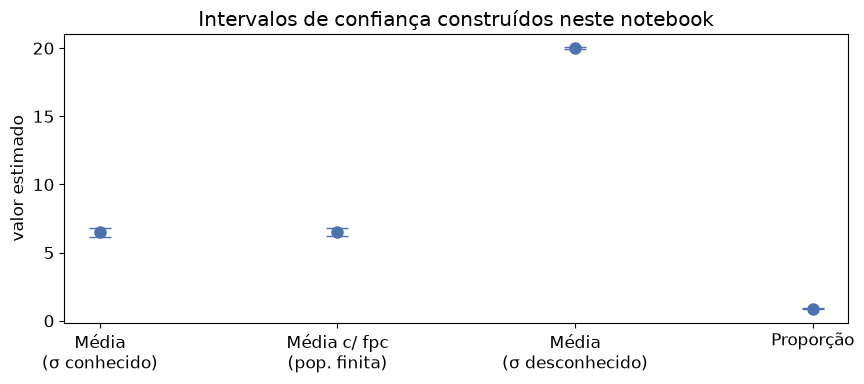

In [8]:
# Visualizando os três tipos de IC construídos, todos como "estimativa ± margem"
fig, ax = plt.subplots(figsize=(9, 4))
casos = ['Média\n(σ conhecido)', 'Média c/ fpc\n(pop. finita)', 'Média\n(σ desconhecido)', 'Proporção']
centros = [media, media, x_barra, p_chapeu]
margens = [margem, margem_corrigida, margem2, margem3]

ax.errorbar(casos, centros, yerr=margens, fmt='o', capsize=8, color='#4C72B0', markersize=8)
ax.set_title('Intervalos de confiança construídos neste notebook')
ax.set_ylabel('valor estimado')
plt.tight_layout()
plt.savefig('img_resumo_intervalos_confianca.png', dpi=110)
plt.show()

## 7. Exercícios de fixação

1. Uma amostra de 40 clientes revelou um gasto médio de R$ 85, com desvio padrão
   populacional conhecido de R$ 20. Construa um IC de 95% para o gasto médio.
2. Uma amostra de 8 lâmpadas testadas até queimar durou, em média, 1200 horas, com
   desvio padrão amostral de 90 horas. Construa um IC de 99% para a vida média (use a
   distribuição t).
3. Numa amostra de 150 eleitores, 63 disseram que votariam no candidato A. Construa um
   IC de 90% para a proporção de eleitores do candidato A.

In [9]:
# 1. IC media, sigma conhecido
z1 = stats.norm.ppf(1 - 0.05 / 2)
m1 = z1 * 20 / math.sqrt(40)
print(f"1) IC 95%: ({85 - m1:.2f}, {85 + m1:.2f})")

# 2. IC media, sigma desconhecido (t, df=7)
t2 = stats.t.ppf(1 - 0.01 / 2, df=7)
m2 = t2 * 90 / math.sqrt(8)
print(f"2) IC 99%: ({1200 - m2:.2f}, {1200 + m2:.2f})")

# 3. IC proporcao
p3 = 63 / 150
z3b = stats.norm.ppf(1 - 0.10 / 2)
m3 = z3b * math.sqrt(p3 * (1 - p3) / 150)
print(f"3) IC 90%: ({p3 - m3:.4f}, {p3 + m3:.4f})")

1) IC 95%: (78.80, 91.20)
2) IC 99%: (1088.65, 1311.35)
3) IC 90%: (0.3537, 0.4863)


## Próximos passos

O próximo notebook,
[`tamanho_amostra_e_testes_hipotese.ipynb`](tamanho_amostra_e_testes_hipotese.ipynb),
inverte o problema — dado o erro máximo tolerável, quantos elementos a amostra precisa
ter? — e faz uma introdução a testes de hipótese usando a mesma lógica do intervalo de
confiança.

## Bibliografia
- TRIOLA, Mario F. *Introdução à Estatística*. 8. ed. Rio de Janeiro: LTC, 2005.
- BUSSAB, Wilton O.; MORETTIN, Pedro A. *Estatística Básica*. 9. ed. São Paulo: Saraiva, 2017.
- MOORE, David S.; McCABE, George P.; CRAIG, Bruce A. *Introduction to the Practice of Statistics*. 9. ed. W. H. Freeman, 2017.
- ANDERSON, David R.; SWEENEY, Dennis J.; WILLIAMS, Thomas A. *Estatística Aplicada à Administração e Economia*. 2. ed. São Paulo: Cengage Learning, 2019.